In [1]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("store_sales.csv")
df

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0
...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0
7296,2023-12-28,10,235.35,0,0
7297,2023-12-29,10,222.82,0,0
7298,2023-12-30,10,236.04,1,0


In [3]:
df.head(5)

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [4]:
df.tail(5)

,date,store,sales,promo,holiday
7295,2023-12-27,10,242.08,0,0
7296,2023-12-28,10,235.35,0,0
7297,2023-12-29,10,222.82,0,0
7298,2023-12-30,10,236.04,1,0
7299,2023-12-31,10,208.29,0,0


In [5]:
df.sample(5)

,date,store,sales,promo,holiday
3838,2022-07-08,6,209.60,0,0
7063,2023-05-09,10,268.41,0,1
6431,2023-08-15,9,263.57,0,0
5632,2023-06-07,8,234.16,0,0
2254,2022-03-06,4,203.20,0,0


In [6]:
df.rename(columns={'store':'store_id'},inplace = True)

In [7]:
df.columns

Index(['date', 'store_id', 'sales', 'promo', 'holiday'], dtype='object')

In [8]:
df['date']=pd.to_datetime(df['date'])

In [9]:
df.head()

,date,store_id,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      7300 non-null   datetime64[ns]
 1   store_id  7300 non-null   int64         
 2   sales     7300 non-null   float64       
 3   promo     7300 non-null   int64         
 4   holiday   7300 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 285.3 KB


In [11]:
df.describe()

,date,store_id,sales,promo,holiday
count,7300,7300.000000,7300.000000,7300.000000,7300.000000
mean,2022-12-31 12:00:00,5.500000,228.434571,0.202192,0.104110
min,2022-01-01 00:00:00,1.000000,160.710000,0.000000,0.000000
25%,2022-07-02 00:00:00,3.000000,209.217500,0.000000,0.000000
50%,2022-12-31 12:00:00,5.500000,226.795000,0.000000,0.000000
75%,2023-07-02 00:00:00,8.000000,245.590000,0.000000,0.000000
max,2023-12-31 00:00:00,10.000000,340.730000,1.000000,1.000000
std,NaN,2.872478,26.625636,0.401662,0.305424


In [12]:
df.isnull().sum()

date        0
store_id    0
sales       0
promo       0
holiday     0
dtype: int64

In [13]:
daily_sales = df.groupby('date')['sales'].sum()

In [14]:
daily_sales

date
2022-01-01    1947.47
2022-01-02    1942.29
2022-01-03    2099.73
2022-01-04    2292.64
2022-01-05    2274.62
               ...   
2023-12-27    2587.33
2023-12-28    2542.60
2023-12-29    2420.24
2023-12-30    2324.81
2023-12-31    2279.99
Name: sales, Length: 730, dtype: float64

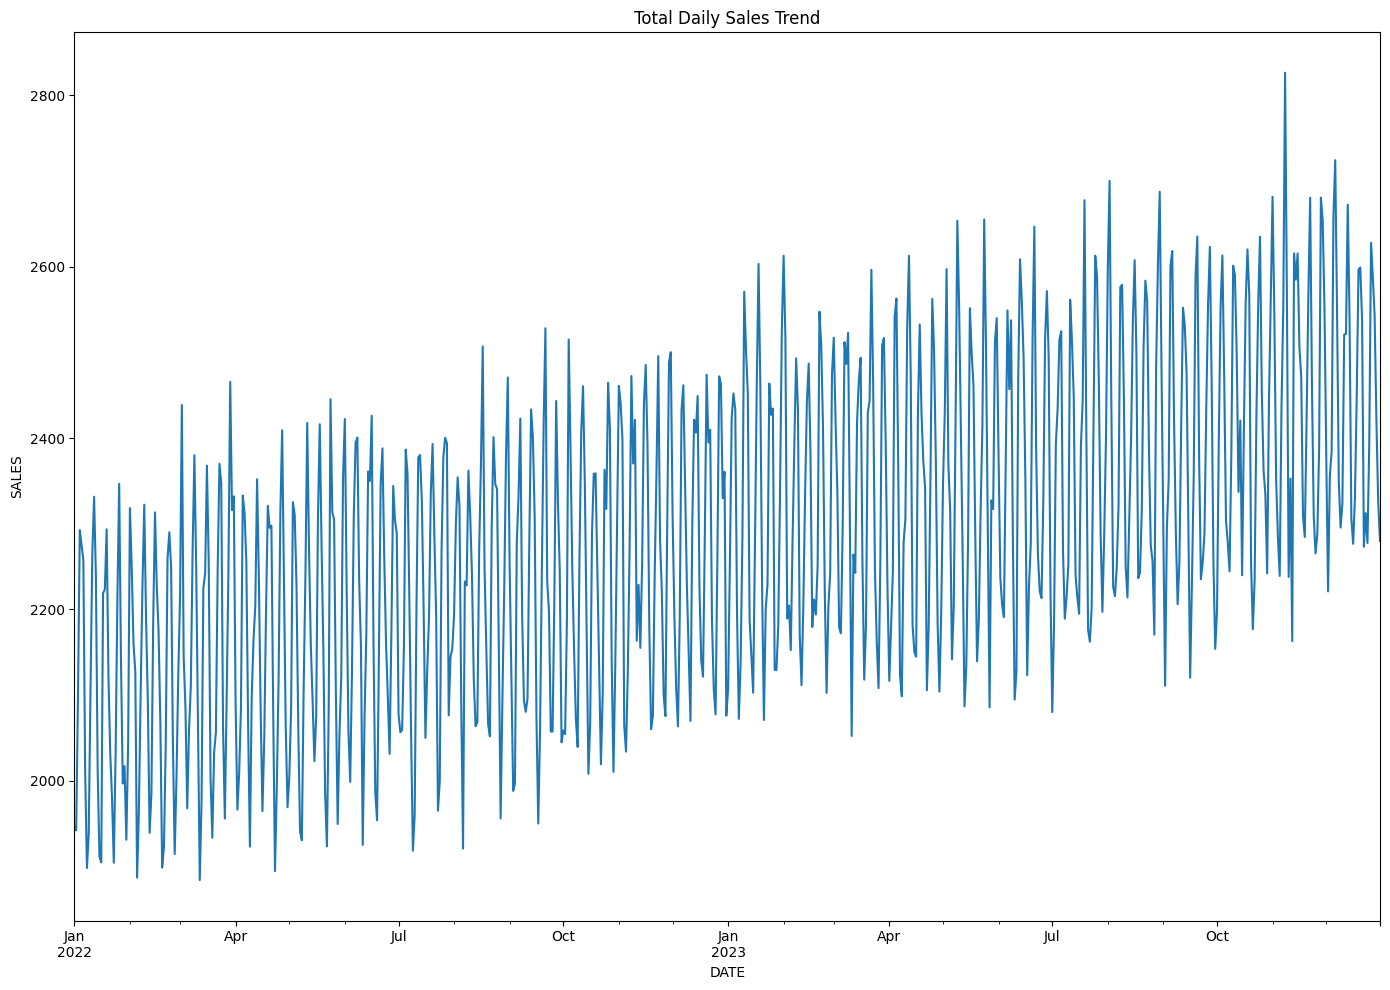

In [15]:
plt.figure(figsize = (14,10))
daily_sales.plot()
plt.title('Total Daily Sales Trend')
plt.xlabel('DATE')
plt.ylabel('SALES')
plt.tight_layout()
plt.show()

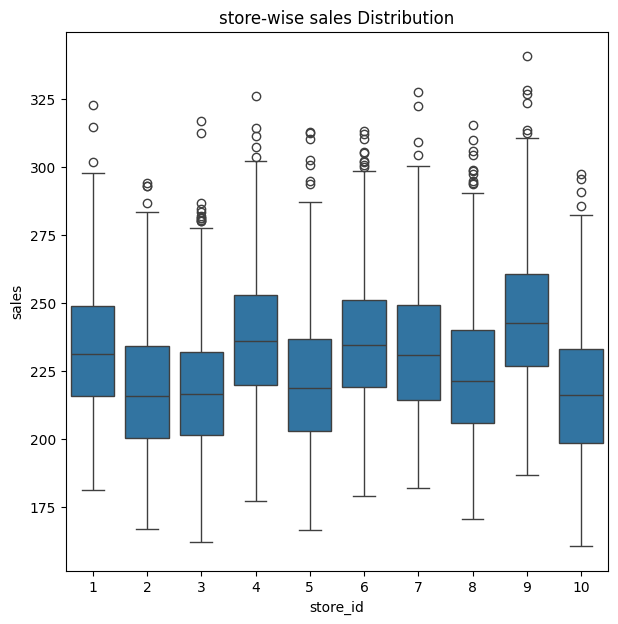

In [16]:
'''plt.figure(figsize = (7,7))
sns.boxplot(x = 'stote_id', y = 'sales', data = df)
plt.title("store-wise sales Distribution")
plt.show()'''
plt.figure(figsize = (7,7))
sns.boxplot(x = 'store_id', y = 'sales', data = df)  # Fixed typo: 'stote_id' -> 'store_id'
plt.title("store-wise sales Distribution")
plt.show()

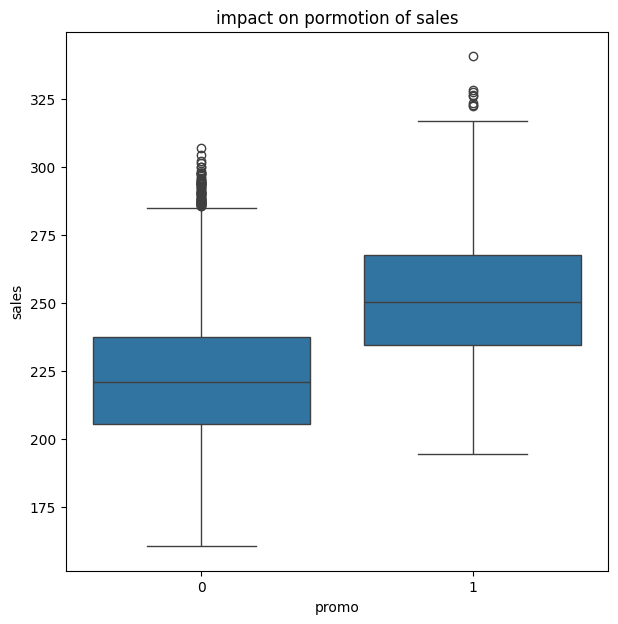

In [17]:
plt.figure(figsize = (7,7))
sns.boxplot(x = 'promo', y = 'sales', data = df)
plt.title('impact on pormotion of sales')
plt.show()

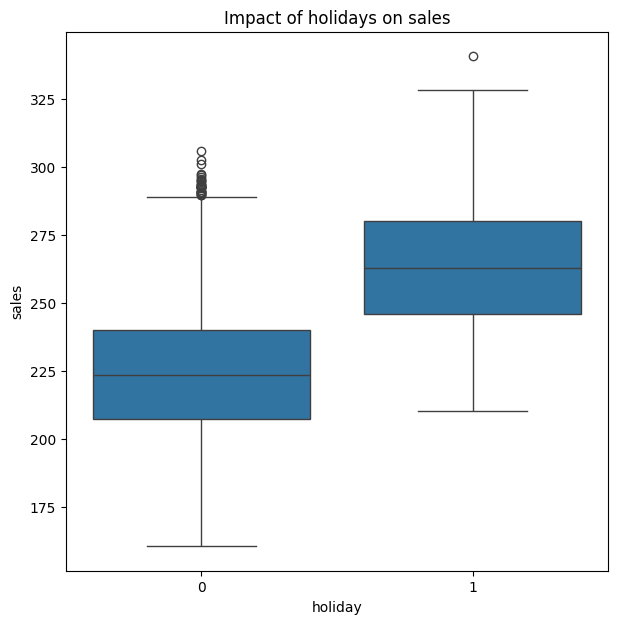

In [18]:
plt.figure(figsize = (7,7))
sns.boxplot(x = 'holiday', y = 'sales', data = df)
plt.title("Impact of holidays on sales")
plt.show()

In [19]:
df = df.sort_values(by = ['store_id','date'])

In [20]:
df['day']= df['date'].dt.day

In [21]:
df

,date,store_id,sales,promo,holiday,day
0,2022-01-01,1,184.78,0,0,1
1,2022-01-02,1,192.62,0,0,2
2,2022-01-03,1,212.68,0,0,3
3,2022-01-04,1,249.58,1,0,4
4,2022-01-05,1,223.50,0,0,5
...,...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0,27
7296,2023-12-28,10,235.35,0,0,28
7297,2023-12-29,10,222.82,0,0,29
7298,2023-12-30,10,236.04,1,0,30


In [22]:
df['month']=df['date'].dt.month

In [23]:
df

,date,store_id,sales,promo,holiday,day,month
0,2022-01-01,1,184.78,0,0,1,1
1,2022-01-02,1,192.62,0,0,2,1
2,2022-01-03,1,212.68,0,0,3,1
3,2022-01-04,1,249.58,1,0,4,1
4,2022-01-05,1,223.50,0,0,5,1
...,...,...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0,27,12
7296,2023-12-28,10,235.35,0,0,28,12
7297,2023-12-29,10,222.82,0,0,29,12
7298,2023-12-30,10,236.04,1,0,30,12


In [24]:
df['year']= df ['date'].dt.year

In [25]:
df

,date,store_id,sales,promo,holiday,day,month,year
0,2022-01-01,1,184.78,0,0,1,1,2022
1,2022-01-02,1,192.62,0,0,2,1,2022
2,2022-01-03,1,212.68,0,0,3,1,2022
3,2022-01-04,1,249.58,1,0,4,1,2022
4,2022-01-05,1,223.50,0,0,5,1,2022
...,...,...,...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0,27,12,2023
7296,2023-12-28,10,235.35,0,0,28,12,2023
7297,2023-12-29,10,222.82,0,0,29,12,2023
7298,2023-12-30,10,236.04,1,0,30,12,2023


In [26]:
df['day_of_week'] = df['date'].dt.dayofweek


In [27]:
df

,date,store_id,sales,promo,holiday,day,month,year,day_of_week
0,2022-01-01,1,184.78,0,0,1,1,2022,5
1,2022-01-02,1,192.62,0,0,2,1,2022,6
2,2022-01-03,1,212.68,0,0,3,1,2022,0
3,2022-01-04,1,249.58,1,0,4,1,2022,1
4,2022-01-05,1,223.50,0,0,5,1,2022,2
...,...,...,...,...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0,27,12,2023,2
7296,2023-12-28,10,235.35,0,0,28,12,2023,3
7297,2023-12-29,10,222.82,0,0,29,12,2023,4
7298,2023-12-30,10,236.04,1,0,30,12,2023,5


In [28]:
df['is_weekend']=df['day_of_week'].isin([5.6]).astype(int)

In [29]:
df.head(100)

,date,store_id,sales,promo,holiday,day,month,year,day_of_week,is_weekend
0,2022-01-01,1,184.78,0,0,1,1,2022,5,0
1,2022-01-02,1,192.62,0,0,2,1,2022,6,0
2,2022-01-03,1,212.68,0,0,3,1,2022,0,0
3,2022-01-04,1,249.58,1,0,4,1,2022,1,0
4,2022-01-05,1,223.50,0,0,5,1,2022,2,0
...,...,...,...,...,...,...,...,...,...,...
95,2022-04-06,1,230.70,0,0,6,4,2022,2,0
96,2022-04-07,1,219.75,0,0,7,4,2022,3,0
97,2022-04-08,1,201.17,0,0,8,4,2022,4,0
98,2022-04-09,1,189.20,0,0,9,4,2022,5,0


In [30]:
df['lag_1']=df.groupby('store_id')['sales'].shift(1)

In [31]:
df

,date,store_id,sales,promo,holiday,day,month,year,day_of_week,is_weekend,lag_1
0,2022-01-01,1,184.78,0,0,1,1,2022,5,0,NaN
1,2022-01-02,1,192.62,0,0,2,1,2022,6,0,184.78
2,2022-01-03,1,212.68,0,0,3,1,2022,0,0,192.62
3,2022-01-04,1,249.58,1,0,4,1,2022,1,0,212.68
4,2022-01-05,1,223.50,0,0,5,1,2022,2,0,249.58
...,...,...,...,...,...,...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0,27,12,2023,2,0,245.07
7296,2023-12-28,10,235.35,0,0,28,12,2023,3,0,242.08
7297,2023-12-29,10,222.82,0,0,29,12,2023,4,0,235.35
7298,2023-12-30,10,236.04,1,0,30,12,2023,5,0,222.82


In [32]:
df['lag_7']=df.groupby('store_id')['sales'].shift(7)

In [33]:
df

,date,store_id,sales,promo,holiday,day,month,year,day_of_week,is_weekend,lag_1,lag_7
0,2022-01-01,1,184.78,0,0,1,1,2022,5,0,NaN,NaN
1,2022-01-02,1,192.62,0,0,2,1,2022,6,0,184.78,NaN
2,2022-01-03,1,212.68,0,0,3,1,2022,0,0,192.62,NaN
3,2022-01-04,1,249.58,1,0,4,1,2022,1,0,212.68,NaN
4,2022-01-05,1,223.50,0,0,5,1,2022,2,0,249.58,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
7295,2023-12-27,10,242.08,0,0,27,12,2023,2,0,245.07,242.42
7296,2023-12-28,10,235.35,0,0,28,12,2023,3,0,242.08,234.22
7297,2023-12-29,10,222.82,0,0,29,12,2023,4,0,235.35,218.08
7298,2023-12-30,10,236.04,1,0,30,12,2023,5,0,222.82,200.09


In [34]:
df['rolling_mean_7']=(df.groupby('store_id')['sales'].shift(1).rolling(7).mean())

In [35]:
df.columns

Index(['date', 'store_id', 'sales', 'promo', 'holiday', 'day', 'month', 'year',
       'day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7'],
      dtype='object')

In [36]:
features=['promo', 'holiday', 'day', 'month','day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']

In [37]:
x=df[features]

In [38]:
y=df['sales']

In [39]:
x

,promo,holiday,day,month,day_of_week,is_weekend,lag_1,lag_7,rolling_mean_7
0,0,0,1,1,5,0,NaN,NaN,NaN
1,0,0,2,1,6,0,184.78,NaN,NaN
2,0,0,3,1,0,0,192.62,NaN,NaN
3,1,0,4,1,1,0,212.68,NaN,NaN
4,0,0,5,1,2,0,249.58,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7295,0,0,27,12,2,0,245.07,242.42,228.747143
7296,0,0,28,12,3,0,242.08,234.22,228.698571
7297,0,0,29,12,4,0,235.35,218.08,228.860000
7298,1,0,30,12,5,0,222.82,200.09,229.537143


In [40]:
y

0       184.78
1       192.62
2       212.68
3       249.58
4       223.50
         ...  
7295    242.08
7296    235.35
7297    222.82
7298    236.04
7299    208.29
Name: sales, Length: 7300, dtype: float64

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=False)

In [42]:
from sklearn.ensemble import RandomForestRegressor
final_model=RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
final_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [43]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
y_pred=final_model.predict(x_test)

In [44]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

MAE: 6.545470731164385
MSE: 68.54188789769918


In [45]:
import joblib
joblib.dump(final_model, "store_sales_model.pkl")


['store_sales_model.pkl']

In [ ]:
! streamlit run stream.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.31:8501

